In [1]:
'''Notable choices were to not include no-plays as they may over represent a players impact on the game'''

'Notable choices were to not include no-plays as they may over represent a players impact on the game'

In [1]:
#Set Up
import pandas as pd
import requests
from io import StringIO
global df, courtland_sutton_involvement, eegbuka_involvement, gpickens_involvement, astbrown_involvement, jchase_involvement, jsn_involvement, pnacua_share_involvement, pdb, pdl, pdc, plr, ptb, pdb, pss
github_url = 'https://github.com/nflverse/nflverse-data/releases/download/pbp/play_by_play_2025.csv'
response = requests.get(github_url)
csv_data = StringIO(response.text)
df = pd.read_csv(
    "play_by_play_2025.csv",
    dtype={
        "play_id": "Int32",
        "old_game_id": "Int32",
        "week": "Int8",
        "drive": "Int8",
        "goal_to_go": "Int8",
        "ydstogo": "Int8",
        "ydsnet": "Int8",
        "yardline_100": "Int8",
        "quarter_seconds_remaining": "Int16",
        "play_type":"string",
        "half_seconds_remaining": "Int16",
        "quarter_end": "Int8",
        "side_of_field": "string",
        "home_team": "string",
        "away_team": "string",
        "game_half": "string",
        "desc": "string",
        "penalty": "Int8",
        
    },
    low_memory=False
)
print("Data loaded successfully!")
df['desc'] = df['desc'].str.replace(r'\xa0', ' ', regex=True)


Data loaded successfully!


In [2]:
#Data Scraping for Troy Franklin
franklin_plays = df[(df['desc'].str.contains("T.Franklin", case=False, na=False))]

troy_franklin_plays = franklin_plays[
    franklin_plays['play_type'].str.contains("pass|run", case=False, na=False)]

data_to_log = ['desc', 'play_type', 'game_half', 'drive', 'qtr', 'down', 'rushing_yards','pass_length'
               'ydstogo', 'first_down_pass', 'first_down_penalty', 'receiving_yards', 'receiver_player_id'
               'third_down_converted', 'third_down_failed', 'fourth_down_converted','yards_after_catch'
               'fourth_down_failed', 'penalty', 'fumbled_1_player_name','td_player_name']
data_to_log = [col for col in data_to_log if col in troy_franklin_plays.columns]

play_log_tf = troy_franklin_plays[data_to_log]
play_log_tf.to_csv("T.Franklin Play Log 2025: Week 1-6.csv", index=False)
print(f"Successful Upload - {len(play_log_tf)} plays logged")

Successful Upload - 39 plays logged


In [3]:
#Data Scraping for Marvin Mims Jr
marvin_mims_plays = df[(df['desc'].str.contains("M.Mims", case=False, na=False))]
marvin_mims_plays = marvin_mims_plays[marvin_mims_plays['play_type'].str.contains("pass|run", case=False, na=False)]
data_to_log = ['desc', 'play_type', 'game_half', 'drive', 'qtr', 'down', 'rushing_yards','pass_length'
               'ydstogo', 'first_down_pass', 'first_down_penalty', 'receiving_yards', 'receiver_player_id'
               'third_down_converted', 'third_down_failed', 'fourth_down_converted','yards_after_catch'
               'fourth_down_failed', 'penalty', 'fumbled_1_player_name','td_player_name']
data_to_log = [col for col in data_to_log if col in marvin_mims_plays.columns]
play_log_tf = marvin_mims_plays[data_to_log]
play_log_tf.to_csv("M.Mims Offensive Play Log 2025: Week 1-6.csv", index=False)
print(f"Successful Upload - {len(play_log_tf)} plays logged")

#Special Teams
broncos_plays = df[(df['posteam'] == 'DEN') | (df['defteam'] == 'DEN')]
marvin_mims_kickoff_punts = broncos_plays[(broncos_plays['play_type'].str.contains("punt|kickoff", case=False, na=False, regex=True)) &
   (broncos_plays['desc'].str.contains("M.Mims", case=False, na=False))]
column_to_log = ['desc', 'play_type', 'game_half', 'qtr','kickoff_fair_catch', 'kickoff_attempt', 'punt_returner_player_name', 
                'kickoff_returner_player_name', 'special_teams_play', ]
column_to_log = [col for col in column_to_log if col in marvin_mims_kickoff_punts.columns]
play_log_tf = marvin_mims_kickoff_punts[column_to_log]
play_log_tf.to_csv("M.Mims Special Teams Play Log 2025: Week 1-6.csv", index=False)
print(f"Successful Upload - {len(play_log_tf)} plays logged")

Successful Upload - 27 plays logged
Successful Upload - 38 plays logged


In [4]:
#Data Scraping for Courtland Sutton

courtland_sutton_plays = df[(df['desc'].str.contains("Sutton", case=False, na=False))]

courtland_sutton_plays = courtland_sutton_plays[courtland_sutton_plays['play_type'].str.contains("pass|run", case=False, na=False)]


data_to_log = ['desc', 'play_type', 'game_half', 'drive', 'qtr', 'down', 'rushing_yards','pass_length'
               'ydstogo', 'first_down_pass', 'first_down_penalty', 'receiving_yards', 'receiver_player_id'
               'third_down_converted', 'third_down_failed', 'fourth_down_converted','yards_after_catch'
               'fourth_down_failed', 'penalty', 'fumbled_1_player_name', 'fumbled_2_player_name','td_player_name']
data_to_log = [col for col in data_to_log if col in courtland_sutton_plays.columns]

play_log_tf = courtland_sutton_plays[data_to_log]
play_log_tf.to_csv("C.Sutton Play Log 2025: Week 1-6.csv", index=False)
print(f"Successful Upload - {len(play_log_tf)} plays logged")

Successful Upload - 40 plays logged


In [5]:
#Testing WR1 Numbers from across the league against Courtland Sutton
#https://www.footballguys.com/stats/snap-counts/teams?team=DAL&year=2025&type=snap-counts, Data Pulled for snap count
global courtland_sutton_involvement, eegbuka_involvement, gpickens_involvement, astbrown_involvement, jchaseinvolvement, pnacua_involvement
from bs4 import BeautifulSoup
import requests
import pandas as pd
dburl = 'https://www.footballguys.com/stats/snap-counts/teams?team=DEN&year=2025&type=snap-counts'
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
}

print("Attempting to fetch URL...")
response = requests.get(dburl, headers=headers)
print(f"Status code: {response.status_code}")
print(f"Content length: {len(response.text)}")

if response.status_code == 200:
    print("\nFirst 1000 characters of response:")
    print(response.text[:1000])
    
    # Try to find tables
    soup = BeautifulSoup(response.content, 'html.parser')
    tables = soup.find_all('table')
    print(f"\nNumber of tables found: {len(tables)}")
    
    # Try pandas read_html
    try:
        dfs = pd.read_html(response.text)
        print(f"Number of tables found by pandas: {len(dfs)}")
        if dfs:
            print("\nFirst table:")
            print(dfs[0].head())
    except Exception as e:
        print(f"Pandas read_html error: {e}")
else:
    print(f"Failed to fetch page. Status: {response.status_code}")

'''def get_snap_counts(Denver):
    url = 'https://www.footballguys.com/stats/snap-counts/teams?team=DEN&year=2025&type=snap-counts'
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
    } 
    response = requests.get(url, headers=headers)
    soup = BeautifulSoup(response.content, 'html.parser')
    table = soup.find('table')
    if table:
        df = pd.read_html(str(table))[0]
        return df
    else:
        print("Could not find table for Denver")
        return None
def get_snap_counts(Denver, Courtland):
    dsc = get_snap_counts(Courtland)
    if dsc is not None:
        courtland_sutton_row = dsc[dsc['Wide Receiver'].str.contains(Courtland, case=False, na=False)]
        if not courtland_sutton_row.empty:
            cs_snap_count = courtland_sutton_row['Total'].values[0]
            return(int(cs_snap_count))
            print(cs_snap_count)
        else:
            print('Found Nothing')
            return(none)
    return(none)
'''
courtland_sutton_plays = df[(df['desc'].str.contains("Sutton", case=False, na=False))]
courtland_sutton_plays = courtland_sutton_plays[courtland_sutton_plays['play_type'].str.contains("pass|run", case=False, na=False)]
courtland_sutton_snap_count = 346
courtland_sutton_involvement = len(courtland_sutton_plays)
courtland_sutton_percentage =(courtland_sutton_involvement/courtland_sutton_snap_count)*100
print("Courtland Sutton:",str(courtland_sutton_percentage)+"% Involvement Percentage")

eegbuka_plays = df[(df['desc'].str.contains("E.Egbuka", case=False, na=False))]
eegbuka_plays = eegbuka_plays[eegbuka_plays['play_type'].str.contains("pass|run", case=False, na=False)]
eegbuka_snap_count = 318
eegbuka_involvement = len(eegbuka_plays)
eegbuka_share_percentage = (eegbuka_involvement/eegbuka_snap_count)*100
print("Emeka Egbuka:",str(eegbuka_share_percentage)+"% Involvement Percentage")

gpickens_plays = df[(df['desc'].str.contains("G.Pickens", case=False, na=False))]
gpickens_plays = gpickens_plays[gpickens_plays['play_type'].str.contains("pass|run", case=False, na=False)]
gpickens_snap_count = 351
gpickens_involvement = len(gpickens_plays)
gpickens_share_percentage = (gpickens_involvement/gpickens_snap_count)*100
print("George Pickens:",str(gpickens_share_percentage)+"% Involvement Percentage")

astbrown_plays = df[(df['desc'].str.contains("A.St. Brown", case=False, na=False))]
astbrown_plays = astbrown_plays[astbrown_plays['play_type'].str.contains("pass|run", case=False, na=False)]
astbrown_snap_count = 323
astbrown_involvement = len(astbrown_plays)
astbrown_share_percentage = (astbrown_involvement/astbrown_snap_count)*100
print("Amon-Ra St.Brown:",str(astbrown_share_percentage)+"% Involvement Percentage")

jchase_plays = df[(df['desc'].str.contains("J.Chase", case=False, na=False))]
jchase_plays = jchase_plays[jchase_plays['play_type'].str.contains("pass|run", case=False, na=False)]
jchase_snap_count = 327
jchase_involvement = len(jchase_plays)
jchase_share_percentage = (jchase_involvement/jchase_snap_count)*100
print("Ja'Marr Chase:",str(jchase_share_percentage)+"% Involvement Percentage")

jsn_plays = df[(df['desc'].str.contains("J.Smith-Njigba", case=False, na=False))]
jsn_plays = jsn_plays[jsn_plays['play_type'].str.contains("pass|run", case=False, na=False)]
jsn_snap_count = 263
jsn_involvement = len(jsn_plays)
jsn_share_percentage =(jsn_involvement/jsn_snap_count)*100
print("Jaxon Smith-Njigba:",str(jsn_share_percentage)+"% Involvement Percentage")

pnacua_plays = df[(df['desc'].str.contains("P.Nacua", case=False, na=False))]
pnacua_plays = pnacua_plays[pnacua_plays['play_type'].str.contains("pass|run", case=False, na=False)]
pnacua_snap_count = 291
pnacua_involvement = len(pnacua_plays)
pnacua_share_percentage = (pnacua_involvement/pnacua_snap_count)*100
print("Puka Nacua:",str(pnacua_share_percentage)+"% Involvement Percentage")

Attempting to fetch URL...
Status code: 200
Content length: 226913

First 1000 characters of response:
<!DOCTYPE html>
<html lang="en">
<head>

    <title>Snap Counts by Team - Footballguys</title>

    <meta http-equiv="X-UA-Compatible" content="IE=edge">
    <meta charset="utf-8">
    <meta name="viewport" content="width=device-width, initial-scale=1">

        <meta name="description" content="Display Snap Counts by Team">
    
        <meta property="og:title" content="Snap Counts by Team">
    <meta property="og:description" content="Display Snap Counts by Team">
    <meta property="og:locale" content="en_US">
    <meta property="og:site_name" content="Footballguys">
        
        <meta name="twitter:card" content="summary_large_image">
    <meta name="twitter:site" content="@Football_Guys">
    <meta name="twitter:creator" content="@Football_Guys">
    <meta name="twitter:title" content="Snap Counts by Team">
    <meta name="twitter:description" content="Display Snap Counts by

/var/folders/d9/vcbvkcs50cd7qwjf4ftpgnc80000gn/T/ipykernel_2228/3134144990.py:28: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  dfs = pd.read_html(response.text)


In [6]:
#Running Game Impact Analysis
#Notable Factors: Egbuka hurt in Week 6, Pickens Became WR1 Week 3 and Forward
#Broncos Analysis
'''First have to scrape for each team and find total number of plays on offense and number of run plays
No Screen plays as it is impossible to descern with the data we have
Calculate Run Percentage for each team and then use that to perform further analysis on passing game 
as then we then can compare how much of the passing offense each of these players constitute
Exclude QB rushes unless were designed'''

Broncos_total_offensive_plays = df[(df['play_type'].str.contains("run|pass", case=False, na=False)) &
    ((df['home_team'] == 'DEN') | (df['away_team'] == 'DEN')) & 
    (df['posteam'] == 'DEN')]
print(str(len(Broncos_total_offensive_plays)))
Broncos_run_plays = df[(df['play_type'].str.contains("run", case=False, na=False)) &
    ((df['home_team'] == 'DEN') | (df['away_team'] == 'DEN')) & 
    (df['posteam'] == 'DEN') &
    (df['qb_scramble'] != '1') &
    (df['play_type'] != 'no_play') &
    (df['qb_scramble'].notna())]
print(str(len(Broncos_run_plays)))

data_to_log_2 = [col for col in data_to_log if col in Broncos_total_offensive_plays.columns]
play_log_total_db = Broncos_total_offensive_plays[data_to_log_2]
data_to_log = [col for col in data_to_log if col in Broncos_run_plays.columns]
play_log_run_db = Broncos_run_plays[data_to_log]

play_log_run_db.to_csv("Broncos Run Play Log 2025: Week 1-6.csv", index=False)
play_log_total_db.to_csv("Broncos Offensive Play Log 2025: Week 1-6.csv", index=False)

print(f"Successful Upload - {len(play_log_run_db)} plays logged")
calc = (len(play_log_run_db)/len(play_log_total_db))*100
print(str(calc)+"%")
pdb = len(play_log_total_db) - len(play_log_run_db)
print(calc)

#Sutton Analysis as % of Offense
cs = int(courtland_sutton_involvement)/len(play_log_total_db)*100
print(cs)

373
160
Successful Upload - 160 plays logged
42.89544235924933%
42.89544235924933
10.723860589812332


In [7]:
#Detroit Analysis
Detroit_total_offensive_plays = df[(df['play_type'].str.contains("run|pass", case=False, na=False)) &
    ((df['home_team'] == 'DET') | (df['away_team'] == 'DET')) & 
    (df['posteam'] == 'DET')]
print(str(len(Detroit_total_offensive_plays)))
Detroit_run_plays = df[(df['play_type'].str.contains("run", case=False, na=False)) &
    ((df['home_team'] == 'DET') | (df['away_team'] == 'DET')) & 
    (df['posteam'] == 'DET') &
    (df['qb_scramble'] != '1') &
    (df['play_type'] != 'no_play') &
    (df['qb_scramble'].notna())]
print(str(len(Detroit_run_plays)))

data_to_total = [col for col in data_to_log if col in Detroit_total_offensive_plays.columns]
play_log_total_dl = Detroit_total_offensive_plays[data_to_log_2]
data_to_log = [col for col in data_to_log if col in Detroit_run_plays.columns]
play_log_run_dl = Detroit_run_plays[data_to_log]

play_log_run_dl.to_csv("Detroit Run Play Log 2025: Week 1-6.csv", index=False)
play_log_total_dl.to_csv("Detroit Offensive Play Log 2025: Week 1-6.csv", index=False)

print(f"Successful Upload - {len(play_log_run_dl)} plays logged")
calc = (len(play_log_run_dl)/len(play_log_total_dl))*100
print(str(calc)+"%")
pdl = len(play_log_total_dl) - len(play_log_run_dl)
print(calc)

#Amon Ra Analysis as % of Offense
ar = (int(astbrown_involvement)/len(play_log_total_dl))*100
print(ar)

353
169
Successful Upload - 169 plays logged
47.875354107648725%
47.875354107648725
15.29745042492918


In [8]:
#Cowboys Analysis
Dallas_total_offensive_plays = df[(df['play_type'].str.contains("run|pass", case=False, na=False)) &
    ((df['home_team'] == 'DAL') | (df['away_team'] == 'DAL')) & 
    (df['posteam'] == 'DAL')]
print(str(len(Detroit_total_offensive_plays)))
Dallas_run_plays = df[(df['play_type'].str.contains("run", case=False, na=False)) &
    ((df['home_team'] == 'DAL') | (df['away_team'] == 'DAL')) & 
    (df['posteam'] == 'DAL') &
    (df['qb_scramble'] != '1') &
    (df['play_type'] != 'no_play') &
    (df['qb_scramble'].notna())]
print(str(len(Dallas_run_plays)))

data_to_log_2 = [col for col in data_to_log if col in Dallas_total_offensive_plays.columns]
play_log_total_dl = Dallas_total_offensive_plays[data_to_log_2]
data_to_log = [col for col in data_to_log if col in Dallas_run_plays.columns]
play_log_run_dl = Dallas_run_plays[data_to_log]

play_log_run_dl.to_csv("Dallas Run Play Log 2025: Week 1-6.csv", index=False)
play_log_total_dl.to_csv("Dallas Offensive Play Log 2025: Week 1-6.csv", index=False)

print(f"Successful Upload - {len(play_log_run_dl)} plays logged")
calc = (len(play_log_run_dl)/len(play_log_total_dl))*100
print(str(calc)+"%")
pdc = len(play_log_total_dl) - len(play_log_run_dl)
print(calc)

#George Pickens Analysis as % of Offense
gp = (int(gpickens_involvement)/len(play_log_total_dl))*100
print(gp)

353
140
Successful Upload - 140 plays logged
36.74540682414698%
36.74540682414698
12.860892388451445


In [9]:
#Rams Analysis
Rams_total_offensive_plays = df[(df['play_type'].str.contains("run|pass", case=False, na=False)) &
    ((df['home_team'] == 'LA') | (df['away_team'] == 'LA')) & 
    (df['posteam'] == 'LA')]
print(str(len(Rams_total_offensive_plays)))
Rams_run_plays = df[(df['play_type'].str.contains("run", case=False, na=False)) &
    ((df['home_team'] == 'LA') | (df['away_team'] == 'LA')) & 
    (df['posteam'] == 'LA') &
    (df['qb_scramble'] != '1') &
    (df['play_type'] != 'no_play') &
    (df['qb_scramble'].notna())]
print(str(len(Rams_run_plays)))

data_to_log_2 = [col for col in data_to_log_2 if col in Rams_total_offensive_plays.columns]
play_log_total_lr = Rams_total_offensive_plays[data_to_log_2]
data_to_log = [col for col in data_to_log if col in Rams_run_plays.columns]
play_log_run_lr = Rams_run_plays[data_to_log]

play_log_run_lr.to_csv("Rams Run Play Log 2025: Week 1-6.csv", index=False)
play_log_total_lr.to_csv("Rams Offensive Play Log 2025: Week 1-6.csv", index=False)

print(f"Successful Upload - {len(play_log_run_lr)} plays logged")
calc = (len(play_log_run_lr)/len(play_log_total_lr))*100
print(str(calc)+"%")
plr = len(play_log_total_lr) - len(play_log_run_lr)
print(calc)

#P Nacua Analysis as % of Offense
pn = (int(pnacua_involvement)/len(play_log_total_lr))*100
print(pn)

356
138
Successful Upload - 138 plays logged
38.764044943820224%
38.764044943820224
19.662921348314608


In [10]:
#Buccaneers Analysis
Bucs_total_offensive_plays = df[(df['play_type'].str.contains("run|pass", case=False, na=False)) &
    ((df['home_team'] == 'TB') | (df['away_team'] == 'TB')) & 
    (df['posteam'] == 'TB')]
print(str(len(Bucs_total_offensive_plays)))
Bucs_run_plays = df[(df['play_type'].str.contains("run", case=False, na=False)) &
    ((df['home_team'] == 'TB') | (df['away_team'] == 'TB')) & 
    (df['posteam'] == 'TB') &
    (df['qb_scramble'] != '1') &
    (df['play_type'] != 'no_play') &
    (df['qb_scramble'].notna())]
print(str(len(Bucs_run_plays)))

data_to_log_2 = [col for col in data_to_log if col in Bucs_total_offensive_plays.columns]
play_log_total_tb = Bucs_total_offensive_plays[data_to_log_2]
data_to_log = [col for col in data_to_log if col in Bucs_run_plays.columns]
play_log_run_tb = Bucs_run_plays[data_to_log]

play_log_run_tb.to_csv("Bucs Run Play Log 2025: Week 1-6.csv", index=False)
play_log_total_tb.to_csv("Bucs Offensive Play Log 2025: Week 1-6.csv", index=False)
print(f"Successful Upload - {len(play_log_total_tb)} plays logged")
calc = (len(play_log_run_tb)/len(play_log_total_tb))*100
print(str(calc)+"%")
ptb = len(play_log_total_tb) - len(play_log_run_tb)
print(calc)

#Egbuka Analysis as % of Offense
ee = (int(eegbuka_involvement)/len(play_log_total_tb))*100
print(ee)

366
160
Successful Upload - 366 plays logged
43.71584699453552%
43.71584699453552
12.295081967213115


In [11]:
#Bengals Analysis
Ben_total_offensive_plays = df[(df['play_type'].str.contains("run|pass", case=False, na=False)) &
    ((df['home_team'] == 'CIN') | (df['away_team'] == 'CIN')) & 
    (df['posteam'] == 'CIN')]
print(str(len(Ben_total_offensive_plays)))
Ben_run_plays = df[(df['play_type'].str.contains("run", case=False, na=False)) &
    ((df['home_team'] == 'CIN') | (df['away_team'] == 'CIN')) & 
    (df['posteam'] == 'CIN') &
    (df['qb_scramble'] != '1') &
    (df['play_type'] != 'no_play') &
    (df['qb_scramble'].notna())]
print(str(len(Ben_run_plays)))

data_to_log_2 = [col for col in data_to_log if col in Ben_total_offensive_plays.columns]
play_log_total_cb = Ben_total_offensive_plays[data_to_log_2]
data_to_log = [col for col in data_to_log if col in Ben_run_plays.columns]
play_log_run_cb = Ben_run_plays[data_to_log]
play_log_run_cb.to_csv("Bengals Run Play Log 2025: Week 1-6.csv", index=False)
play_log_total_cb.to_csv("Bengals Offensive Play Log 2025: Week 1-6.csv", index=False)
print(f"Successful Upload - {len(play_log_run_cb)} plays logged")
calc = (len(play_log_run_cb)/len(play_log_total_cb))*100
print(str(calc)+"%")
pcb = len(play_log_total_cb) - len(play_log_run_cb)
print(calc)

#Chase Analysis as % of Offense
jc = (int(jchase_involvement)/len(play_log_total_cb))*100
print(jc)

327
107
Successful Upload - 107 plays logged
32.7217125382263%
32.7217125382263
18.654434250764528


In [12]:
#Seahawks Analysis
Sea_total_offensive_plays = df[(df['play_type'].str.contains("run|pass|no_play", case=False, na=False)) &
    ((df['home_team'] == 'SEA') | (df['away_team'] == 'SEA')) & 
    (df['posteam'] == 'SEA')]
print(str(len(Sea_total_offensive_plays)))
Sea_run_plays = df[(df['play_type'].str.contains("run", case=False, na=False)) &
    ((df['home_team'] == 'SEA') | (df['away_team'] == 'SEA')) & 
    (df['posteam'] == 'SEA') &
    (df['qb_scramble'] != '1') &
    (df['play_type'] != 'no_play') &
    (df['qb_scramble'].notna())]
print(str(len(Ben_run_plays)))

data_to_log_2 = [col for col in data_to_log_2 if col in Sea_total_offensive_plays.columns]
play_log_total_ss = Sea_total_offensive_plays[data_to_log_2]
data_to_log = [col for col in data_to_log if col in Sea_run_plays.columns]
play_log_run_ss = Sea_run_plays[data_to_log]

play_log_total_ss.to_csv("Seattle Run Play Log 2025: Week 1-6.csv", index=False)
play_log_run_ss.to_csv("Seattle Offensive Play Log 2025: Week 1-6.csv", index=False)
print(f"Successful Upload - {len(play_log_tf)} plays logged")
calc = (len(play_log_run_ss)/len(play_log_total_ss))*100
print(str(calc)+"%")
pss = len(play_log_total_ss) - len(play_log_run_ss)
print(calc)

#JSN Analysis as % of Offense
jsn = (int(jchase_involvement)/len(play_log_total_ss))*100
print(jsn)

356
107
Successful Upload - 40 plays logged
46.348314606741575%
46.348314606741575
17.134831460674157


In [13]:
'''Looking at the numbers in general we can see that sutton is not where he is supposed to be. 
Yes, Brown and Chase both lineup in the slot more than sutton, but look at George Pickens. 
He jumped into the role of being WR1 and isstill a full 2% higher than Sutton. On top of this Dallas has a solid run game too 
and when evaluating from '''

'Looking at the numbers in general we can see that sutton is not where he is supposed to be. \nYes, Brown and Chase both lineup in the slot more than sutton, but look at George Pickens. \nHe jumped into the role of being WR1 and isstill a full 2% higher than Sutton. On top of this Dallas has a solid run game too \nand when evaluating from '

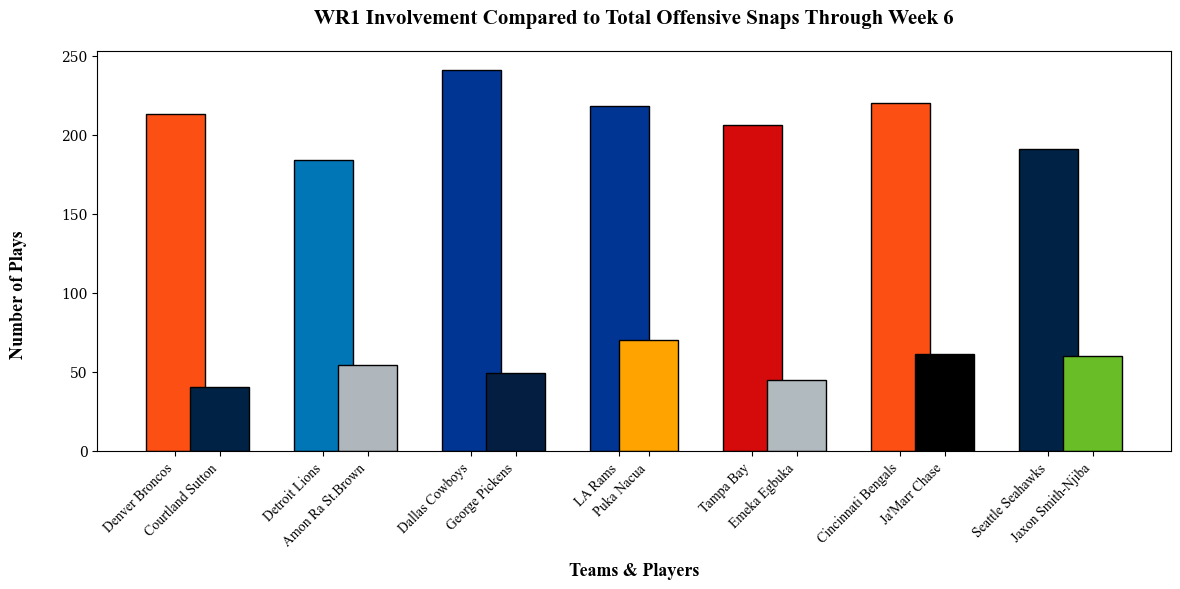

In [17]:
#Making the Graphs
import matplotlib.pyplot as plt
import seaborn as sns
data = {
    'Denver Broncos': pdb,
    'Courtland Sutton': courtland_sutton_involvement,
    'Detroit Lions': pdl,
    'Amon Ra St.Brown': astbrown_involvement,
    'Dallas Cowboys':pdc,
    'George Pickens':gpickens_involvement,
    'LA Rams':plr,
    'Puka Nacua':pnacua_involvement,
    'Tampa Bay':ptb,
    'Emeka Egbuka':eegbuka_involvement,
    'Cincinnati Bengals':pcb,
    "Ja'Marr Chase":jchase_involvement,
    'Seattle Seahawks':pss,
    'Jaxon Smith-Njiba':jsn_involvement
}

categories = list(data.keys())
values = list(data.values())
positions = [0,0.6,2,2.6,4,4.6,6,6.4,7.8,8.4,9.8,10.4,11.8,12.4]
colors = [
    '#FB4F14',  # Denver Broncos
    '#002244',  # Courtland Sutton
    '#0076B6',  # Detroit Lions
    '#B0B7BC',  # Amon Ra St.Brown
    '#003594',  # Dallas Cowboys
    '#041E42',  # George Pickens
    '#003594',  # LA Rams
    '#FFA300',  # Puka Nacua
    '#D50A0A',  # Tampa Bay
    '#B1BABF',  # Emeka Egbuka
    '#FB4F14',  # Cincinnati Bengals
    '#000000',  # Ja'Marr Chase
    '#002244',  # Seattle Seahawks
    '#69BE28'   # Jaxon Smith-Njiba
]

plt.figure(figsize=(12, 6))
plt.bar(positions, values, color=colors, edgecolor='black')

plt.xticks(positions, categories, rotation=45, ha='right', fontsize=10, fontfamily='Times new Roman')
plt.yticks(fontsize=10, fontfamily='serif')

plt.xlabel('Teams & Players', fontsize=13, fontweight='bold', fontfamily='Times New Roman', labelpad=10)

plt.title('WR1 Involvement Compared to Total Offensive Snaps Through Week 6', fontsize=15, fontweight='bold', fontfamily='Times New Roman', pad=20)

fig = plt.gcf()
fig.text(0.02, 0.5, 'Number of Plays', va='center', rotation='vertical', fontsize=13, fontweight='bold', fontfamily='Times New Roman')

plt.tight_layout(rect=[0.05, 0, 1, 1])
plt.show()